# 05 - Hybrid Feature Engineering
Goal: see whether adding handcrafted feature families on top of the word-level TF-IDF backbone (chosen in `04`) improves results, especially on the contextual priority task. The headline comparison is **text-only vs all-hybrid** on both the stratified and grouped-by-subject splits.

Feature families added on top of the backbone:

| family | what it is | source |
| --- | --- | --- |
| **length**   | numeric character / word counts | `frozen_dataset.csv` |
| **language** | function-word ratios + `lang_proxy` | `frozen_dataset.csv` |
| **metadata** | sender domain, attachments, recipients, date/time | `emails_export.csv` joined on `id` |
| **regex**    | dates, times, bracket tags, `re:`, punctuation, capitalization | raw `subject` + `body_plain` |
| **lexicon**  | small Italian + English dictionaries (urgency / academic / event / ad) | raw `subject_body` |


## 1 — Imports and configuration


In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GroupShuffleSplit,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, f1_score,
)

warnings.filterwarnings("ignore")

FROZEN_PATH = Path("../data/processed/frozen_dataset.csv")
META_PATH   = Path("../data/raw/emails_export.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2

TOPIC_ORDER = ["administrative", "course-exam", "event", "deadline-action", "advertisement"]
PRIORITY_ORDER = ["High", "Medium", "Low"]
TASK_LABELS = {"topic": TOPIC_ORDER, "priority": PRIORITY_ORDER}

# Backbone choices, locked from 04.
BACKBONE_FIELD = {"topic": "text_subject_body", "priority": "text_body"}

TFIDF_KWARGS = dict(
    analyzer="word", ngram_range=(1, 2),
    min_df=2, max_df=0.95, sublinear_tf=True, lowercase=False,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 80)
print("Frozen :", FROZEN_PATH.resolve())
print("Meta   :", META_PATH.resolve())


Frozen : D:\UniGe\3\NLP\NLP-project\Preprocessing\frozen_dataset.csv
Meta   : D:\UniGe\3\NLP\NLP-project\emails_export.csv


## 2 — Load frozen + metadata, join on `id`

`emails_export.csv` is the raw export. We only **read it for the IDs that exist in `frozen_dataset.csv`** — never modify either file. Missing values get safe defaults (1 frozen row has no metadata match).


In [2]:
df = pd.read_csv(FROZEN_PATH)
for col in ["text_subject", "text_body", "text_subject_body", "subject", "body_plain"]:
    df[col] = df[col].fillna("").astype(str)

# Read only the metadata columns we actually need; index by id for a left join.
meta_cols = ["id", "date_iso", "from", "from_domain", "to", "cc",
             "has_attachment", "attachment_count"]
meta = pd.read_csv(META_PATH, usecols=meta_cols)
meta = meta.drop_duplicates(subset="id").set_index("id")

joined_idx = df["id"].map(lambda x: meta.index.get_loc(x) if x in meta.index else None)
matched = df["id"].isin(meta.index)
print(f"Joined rows: {matched.sum()} / {len(df)} (missing: {(~matched).sum()})")

df["from"]             = df["id"].map(meta["from"]).fillna("")
df["from_domain"]      = df["id"].map(meta["from_domain"]).fillna("unknown")
df["to"]               = df["id"].map(meta["to"]).fillna("")
df["cc"]               = df["id"].map(meta["cc"]).fillna("")
df["date_iso"]         = df["id"].map(meta["date_iso"])
df["has_attachment"]   = df["id"].map(meta["has_attachment"])
df["attachment_count"] = df["id"].map(meta["attachment_count"])

# Coerce dtypes (Excel exports vary).
df["has_attachment"]   = df["has_attachment"].astype(str).str.upper().eq("TRUE").astype(int)
df["attachment_count"] = pd.to_numeric(df["attachment_count"], errors="coerce").fillna(0).astype(int)

print("Top from_domain values:")
print(df["from_domain"].value_counts().head(8).to_string())


Joined rows: 918 / 919 (missing: 1)
Top from_domain values:
from_domain
unige.it               501
liste.unige.it         278
ecomm.lenovo.com        39
business.lenovo.com     25
gmail.com               12
perform.unige.it        11
edu.unige.it             9
studenti.unige.it        9


## 3 — Splits (same as 03 / 04)


In [3]:
indices = np.arange(len(df))

idx_train_topic, idx_test_topic = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["topic"].values,
)
idx_train_priority, idx_test_priority = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["priority"].values,
)
SPLITS_STRAT = {
    "topic":    (idx_train_topic, idx_test_topic),
    "priority": (idx_train_priority, idx_test_priority),
}

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
SPLITS_GROUPED = next(gss.split(indices, groups=df["text_subject"].values))

print(f"Stratified topic   : {len(idx_train_topic):>4} / {len(idx_test_topic):>4}")
print(f"Stratified priority: {len(idx_train_priority):>4} / {len(idx_test_priority):>4}")
print(f"Grouped subject    : {len(SPLITS_GROUPED[0]):>4} / {len(SPLITS_GROUPED[1]):>4}")


Stratified topic   :  735 /  184
Stratified priority:  735 /  184
Grouped subject    :  727 /  192


## 4 — Build the five non-text feature families

We keep each family deliberately small. The point is to **add interpretable signal** to the TF-IDF backbone, not to recreate the vectorizer.

### 4.1 Length (6 numeric)


In [4]:
df["subject_char_len"]      = df["text_subject"].str.len()
df["subject_word_len"]      = df["text_subject"].str.split().str.len().fillna(0).astype(int)
df["body_char_len"]         = df["text_body"].str.len()
df["body_word_len"]         = df["text_body"].str.split().str.len().fillna(0).astype(int)
df["subject_body_char_len"] = df["text_subject_body"].str.len()
df["subject_body_word_len"] = df["text_subject_body"].str.split().str.len().fillna(0).astype(int)

LENGTH_FEATURES = [
    "subject_char_len", "subject_word_len",
    "body_char_len", "body_word_len",
    "subject_body_char_len", "subject_body_word_len",
]
print("Length features:", LENGTH_FEATURES)


Length features: ['subject_char_len', 'subject_word_len', 'body_char_len', 'body_word_len', 'subject_body_char_len', 'subject_body_word_len']


### 4.2 Language proxy (5 numeric + categorical)


In [5]:
ITALIAN_FW = {"il","lo","la","i","gli","le","di","a","da","in","con","per","che",
              "non","una","un","sono","del","della","alle","agli","entro","iscrizione"}
ENGLISH_FW = {"the","and","of","to","in","for","with","is","are","you","your",
              "this","that","by","from","on","at","deadline","submit"}
WORD_RE = re.compile(r"[A-Za-z\u00C0-\u017F][A-Za-z\u00C0-\u017F\-_]*")


def _lang_features(text):
    toks = WORD_RE.findall(text.lower())
    n = len(toks)
    if n == 0:
        return 0, 0, 0.0, 0.0, "unknown"
    it = sum(1 for t in toks if t in ITALIAN_FW)
    en = sum(1 for t in toks if t in ENGLISH_FW)
    it_r, en_r = it / n, en / n
    if it_r == 0 and en_r == 0:        proxy = "unknown"
    elif it_r >= 1.5 * en_r and it_r > 0.01:  proxy = "it"
    elif en_r >= 1.5 * it_r and en_r > 0.01:  proxy = "en"
    else:                                     proxy = "mixed"
    return it, en, it_r, en_r, proxy


lang = df["text_subject_body"].apply(_lang_features).tolist()
df["italian_fw_count"] = [r[0] for r in lang]
df["english_fw_count"] = [r[1] for r in lang]
df["italian_ratio"]    = [r[2] for r in lang]
df["english_ratio"]    = [r[3] for r in lang]
df["lang_proxy"]       = [r[4] for r in lang]

LANG_NUM = ["italian_fw_count", "english_fw_count", "italian_ratio", "english_ratio"]
LANG_CAT = ["lang_proxy"]
print("Language proxy distribution:")
print(df["lang_proxy"].value_counts().to_string())


Language proxy distribution:
lang_proxy
it       554
en       242
mixed    123


### 4.3 Metadata (from `emails_export.csv`)

- `from_domain` — top-12 most frequent domains, everything else → `other`.
- `has_attachment`, `attachment_count`.
- Recipient counts from `to` and `cc`.
- Time features parsed from `date_iso` — hour of day, day-of-week one-hot, weekend / morning flags.


In [ ]:
TOP_DOMAINS = (df["from_domain"].value_counts().head(12).index.tolist())
df["from_domain_top"] = df["from_domain"].where(df["from_domain"].isin(TOP_DOMAINS), other="other")

df["n_recipients"] = (df["to"].str.count(",") + 1) * (df["to"] != "").astype(int)
df["n_cc"]         = (df["cc"].str.count(",") + 1) * (df["cc"] != "").astype(int)
df["has_cc"]       = (df["cc"] != "").astype(int)

# Extract date features; -1 for missing/invalid dates.
dt = pd.to_datetime(df["date_iso"], errors="coerce", utc=True)
df["hour"]       = dt.dt.hour.fillna(-1).astype(int)
df["dayofweek"]  = dt.dt.dayofweek.fillna(-1).astype(int)
df["is_weekend"] = dt.dt.dayofweek.isin([5, 6]).astype(int)
df["is_morning"] = dt.dt.hour.between(6, 11, inclusive="both").fillna(False).astype(int)
df["is_evening"] = dt.dt.hour.between(18, 23, inclusive="both").fillna(False).astype(int)
# Note: we don't consider "is_afternoon" since it's mostly complementary to the other two.
META_NUM = ["attachment_count", "n_recipients", "n_cc",
            "hour", "is_weekend", "is_morning", "is_evening", "has_attachment", "has_cc"]
META_CAT = ["from_domain_top", "dayofweek"]
print(f"Top domains kept ({len(TOP_DOMAINS)}):", TOP_DOMAINS)
print()
print("dayofweek distribution (0=Mon ... 6=Sun, -1=missing):")
print(df["dayofweek"].value_counts().sort_index().to_string())


Top domains kept (12): ['unige.it', 'liste.unige.it', 'ecomm.lenovo.com', 'business.lenovo.com', 'gmail.com', 'perform.unige.it', 'edu.unige.it', 'studenti.unige.it', 'telecom-paris.fr', 'segreterie.unige.it', 'ext.unige.it', 'dibris.unige.it']

dayofweek distribution (0=Mon ... 6=Sun, -1=missing):
dayofweek
-1      1
 0    171
 1    188
 2    185
 3    159
 4    150
 5     32
 6     33


### 4.4 Regex / rule features

Patterns over the **raw** `subject` + `body_plain` (case preserved, unlike the cleaned text).

- `has_date` / `has_time` — explicit date and time tokens.
- `bracket_tag` — starts with `[studenti]`, `[studenti-mfn]`, etc.
- `starts_with_re` — reply / forward thread.
- `exclamation_count` / `question_count` / `caps_word_ratio`.


In [ ]:
DATE_RE = re.compile(r"\b\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}\b|\b\d{1,2}\s+(?:gennaio|febbraio|marzo|aprile|maggio|giugno|luglio|agosto|settembre|ottobre|novembre|dicembre|january|february|march|april|may|june|july|august|september|october|november|december)\b", re.IGNORECASE)
TIME_RE   = re.compile(r"\b\d{1,2}[:.]\d{2}\b")
BRACKET_RE = re.compile(r"^\s*\[([^\]]{1,40})\]")
RE_PREFIX  = re.compile(r"^\s*(re:|ri:|fwd:|fw:|r:)", re.IGNORECASE)
CAPS_WORD  = re.compile(r"\b[A-Z]{3,}\b")


def _regex_features(subject_raw, body_raw):
    # Combine subject and body for regex searching; subject may be None.
    subj = subject_raw or ""
    body = body_raw or ""
    full = f"{subj} {body}"

    has_date    = int(bool(DATE_RE.search(full)))
    has_time    = int(bool(TIME_RE.search(full)))
    n_dates     = len(DATE_RE.findall(full))
    n_times     = len(TIME_RE.findall(full))
    starts_re   = int(bool(RE_PREFIX.match(subj)))
    n_excl      = full.count("!")
    n_quest     = full.count("?")
    bm = BRACKET_RE.match(subj)
    bracket_tag = bm.group(1).strip().lower() if bm else "none"
    words = subj.split()
    caps_ratio  = (sum(1 for w in words if CAPS_WORD.fullmatch(w)) / max(len(words), 1))
    return has_date, has_time, n_dates, n_times, starts_re, n_excl, n_quest, bracket_tag, caps_ratio

# Extract regex-based features.
reg = df.apply(lambda r: _regex_features(r["subject"], r["body_plain"]), axis=1).tolist()
(df["has_date"], df["has_time"], df["n_dates"], df["n_times"],
 df["starts_with_re"], df["n_excl"], df["n_quest"],
 df["bracket_tag"], df["caps_ratio"]) = map(list, zip(*reg))

# Collapse rare bracket tags to "other".
TOP_BRACKETS = df["bracket_tag"].value_counts().head(8).index.tolist()
df["bracket_tag"] = df["bracket_tag"].where(df["bracket_tag"].isin(TOP_BRACKETS), other="other")

REGEX_NUM = ["has_date", "has_time", "n_dates", "n_times",
             "starts_with_re", "n_excl", "n_quest", "caps_ratio"]
REGEX_CAT = ["bracket_tag"]
print("Top bracket tags:")
print(df["bracket_tag"].value_counts().to_string())


Top bracket tags:


bracket_tag
none                   501
studenti               350
studenti-mfn            33
studenticorsilaurea     10
studenti 10852           9
dope_aerospace           6
other                    4
dopehubs                 4
studenti-mfn-mag         2


### 4.5 Lexical-semantic features

Four small bilingual lexicons. For each, we count how many lexicon words appear in the cleaned `text_subject_body`. Counts are normalized by document length to avoid the long-document trap.

- **urgency** — pulls toward `High` / `deadline-action`.
- **academic** — pulls toward `course-exam`.
- **event** — pulls toward `event`.
- **ad** — pulls toward `advertisement`.


In [8]:
URGENCY_LEX = {
    # Italian
    "scadenza","scade","entro","urgente","urgenti","ricordo","promemoria",
    "attenzione","importante","importanti","ultimo","ultima","oggi","domani",
    "stasera","subito","tassativo",
    # English
    "deadline","urgent","asap","important","reminder","please","today",
    "tomorrow","expires","expire","last",
}
ACADEMIC_LEX = {
    "esame","lezione","corso","aula","prenotazione","voto","esito","iscrizione",
    "appello","prova","prof","professore","laurea","tesi",
    "exam","lecture","course","classroom","registration","grade","professor","lab",
    "thesis","seminar",
}
EVENT_LEX = {
    "evento","conferenza","seminario","workshop","presentazione","convegno",
    "festival","incontro","mostra","cerimonia",
    "event","conference","talk","meeting","ceremony","exhibition",
}
AD_LEX = {
    "sconto","offerta","promozione","promo","saldo","speciale","gratuito","gratis",
    "discount","offer","sale","deal","free","save","limited","exclusive",
}


def _lex_score(text, lex):
    toks = WORD_RE.findall(text.lower())
    if not toks:
        return 0.0
    return sum(1 for t in toks if t in lex) / len(toks)


df["lex_urgency"]  = df["text_subject_body"].apply(lambda t: _lex_score(t, URGENCY_LEX))
df["lex_academic"] = df["text_subject_body"].apply(lambda t: _lex_score(t, ACADEMIC_LEX))
df["lex_event"]    = df["text_subject_body"].apply(lambda t: _lex_score(t, EVENT_LEX))
df["lex_ad"]       = df["text_subject_body"].apply(lambda t: _lex_score(t, AD_LEX))

LEX_NUM = ["lex_urgency", "lex_academic", "lex_event", "lex_ad"]
print(df[LEX_NUM].describe().round(4).T[["mean", "std", "max"]])


                mean     std     max
lex_urgency   0.0081  0.0159  0.1094
lex_academic  0.0178  0.0234  0.1333
lex_event     0.0029  0.0070  0.0690
lex_ad        0.0011  0.0061  0.1111


## 5 — Build the hybrid `ColumnTransformer`

Each family is a separate transformer so we can switch them on/off for ablation. The TF-IDF backbone is the only family that operates on a *string* column; everything else is numeric or categorical.


In [9]:
TEXT_COL = "_text"  # placeholder; we set it per task in the runner


def build_hybrid_pipeline(families: set, text_col: str = TEXT_COL):
    transformers = []
    if "text" in families:
        transformers.append(("text", TfidfVectorizer(**TFIDF_KWARGS), text_col))
    if "length" in families:
        transformers.append(("length", StandardScaler(), LENGTH_FEATURES))
    if "language" in families:
        transformers.append(("lang_num", StandardScaler(), LANG_NUM))
        transformers.append(("lang_cat", OneHotEncoder(handle_unknown="ignore"), LANG_CAT))
    if "metadata" in families:
        transformers.append(("meta_num", StandardScaler(), META_NUM))
        transformers.append(("meta_cat", OneHotEncoder(handle_unknown="ignore"), META_CAT))
    if "regex" in families:
        transformers.append(("regex_num", StandardScaler(), REGEX_NUM))
        transformers.append(("regex_cat", OneHotEncoder(handle_unknown="ignore"), REGEX_CAT))
    if "lexicon" in families:
        transformers.append(("lex", StandardScaler(), LEX_NUM))
    pre = ColumnTransformer(transformers, remainder="drop", sparse_threshold=0.3)
    return Pipeline([("pre", pre),
                     ("clf", LinearSVC(class_weight="balanced", max_iter=5000))])


print("Hybrid pipeline factory ready.")


Hybrid pipeline factory ready.


## 6 — Helpers (CV, evaluate, record)


In [10]:
def cv_macro_f1(estimator, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(estimator, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return float(scores.mean()), float(scores.std())


def evaluate(estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0)
    return estimator, y_pred, {
        "accuracy":         accuracy_score(y_test, y_pred),
        "macro_precision":  p,
        "macro_recall":     r,
        "macro_f1":         f,
        "weighted_f1":      f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }


RESULTS = []
PREDS = {}


def record(task, split_type, families, metrics, cv_mean=None, cv_std=None, n_features=None):
    row = {
        "task": task, "split_type": split_type,
        "families": "+".join(sorted(families)),
        "cv_macro_f1_mean": None if cv_mean is None else round(cv_mean, 4),
        "cv_macro_f1_std":  None if cv_std  is None else round(cv_std,  4),
        "num_features": n_features,
        **{k: round(v, 4) for k, v in metrics.items()},
    }
    RESULTS.append(row)
    return row


print("Helpers ready.")


Helpers ready.


## 7 — Text-only vs all-hybrid (with per-family ablation)

The report compares **text-only** against **text + all hybrid features** on both splits. The single-family rows (text + length, + language, + metadata, + regex, + lexicon) are an optional per-family ablation beyond the report. The all-hybrid and text-only models are also evaluated under the grouped-by-subject split.


In [ ]:
ABLATION = [
    ("text",                              {"text"}),
    ("text+length",                       {"text", "length"}),
    ("text+language",                     {"text", "language"}),
    ("text+metadata",                     {"text", "metadata"}),
    ("text+regex",                        {"text", "regex"}),
    ("text+lexicon",                      {"text", "lexicon"}),
    ("text+all",                          {"text", "length", "language", "metadata", "regex", "lexicon"}),
]


def run_ablation(task: str):
    field = BACKBONE_FIELD[task]
    df_task = df.copy()
    df_task[TEXT_COL] = df_task[field]

    idx_tr, idx_te = SPLITS_STRAT[task]
    X_tr, X_te = df_task.loc[idx_tr], df_task.loc[idx_te]
    y_tr = df_task.loc[idx_tr, task].values
    y_te = df_task.loc[idx_te, task].values

    print(f"\n=== {task.upper()} (backbone field = {field}) ===")
    for name, fam in ABLATION:
        pipe = build_hybrid_pipeline(fam)
        cv_m, cv_s = cv_macro_f1(pipe, X_tr, y_tr)
        pipe = build_hybrid_pipeline(fam)
        pipe, y_pred, metrics = evaluate(pipe, X_tr, y_tr, X_te, y_te)
        n_feat = pipe.named_steps["pre"].transform(X_tr.iloc[:1]).shape[1]
        record(task, "stratified", fam, metrics, cv_m, cv_s, n_feat)
        PREDS[(task, name, "stratified")] = (y_te, y_pred)
        print(f"[strat]   {name:<16} | CV={cv_m:.3f}±{cv_s:.3f} | "
              f"acc={metrics['accuracy']:.3f} macroF1={metrics['macro_f1']:.3f} "
              f"| n_feat={n_feat}")

    # Grouped-by-subject for the all-hybrid model and for text-only as reference.
    idx_tr_g, idx_te_g = SPLITS_GROUPED
    X_tr_g, X_te_g = df_task.loc[idx_tr_g], df_task.loc[idx_te_g]
    y_tr_g = df_task.loc[idx_tr_g, task].values
    y_te_g = df_task.loc[idx_te_g, task].values
    for name, fam in [("text", {"text"}),
                      ("text+all", {"text","length","language","metadata","regex","lexicon"})]:
        pipe = build_hybrid_pipeline(fam)
        pipe, y_pred, metrics = evaluate(pipe, X_tr_g, y_tr_g, X_te_g, y_te_g)
        n_feat = pipe.named_steps["pre"].transform(X_tr_g.iloc[:1]).shape[1]
        record(task, "grouped_subject", fam, metrics, n_features=n_feat)
        PREDS[(task, name, "grouped_subject")] = (y_te_g, y_pred)
        print(f"[grouped] {name:<16} | acc={metrics['accuracy']:.3f} "
              f"macroF1={metrics['macro_f1']:.3f} | n_feat={n_feat}")


for task in ("topic", "priority"):
    run_ablation(task)



=== TOPIC (backbone field = text_subject_body) ===


[strat]   text             | CV=0.844±0.035 | acc=0.870 macroF1=0.861 | n_feat=23341


[strat]   text+length      | CV=0.827±0.032 | acc=0.859 macroF1=0.846 | n_feat=23347


[strat]   text+language    | CV=0.837±0.037 | acc=0.870 macroF1=0.861 | n_feat=23348


[strat]   text+metadata    | CV=0.819±0.022 | acc=0.859 macroF1=0.846 | n_feat=23371


...

[strat]   text+metadata    | CV=0.730±0.038 | acc=0.761 macroF1=0.757 | n_feat=22633


[strat]   text+regex       | CV=0.735±0.038 | acc=0.750 macroF1=0.748 | n_feat=22620


[strat]   text+lexicon     | CV=0.740±0.036 | acc=0.755 macroF1=0.754 | n_feat=22607


[strat]   text+all         | CV=0.748±0.030 | acc=0.750 macroF1=0.747 | n_feat=22667
[grouped] text             | acc=0.682 macroF1=0.684 | n_feat=22889


[grouped] text+all         | acc=0.740 macroF1=0.739 | n_feat=22953


## 8 — Results tables

Stratified ablation per task, plus stratified-vs-grouped for the all-hybrid model.


In [12]:
results_df = pd.DataFrame(RESULTS)
ablation_df = (results_df[results_df["split_type"] == "stratified"]
               .sort_values(["task", "macro_f1"], ascending=[True, False]))
ablation_df[["task", "families", "cv_macro_f1_mean", "cv_macro_f1_std",
             "accuracy", "macro_precision", "macro_recall", "macro_f1",
             "weighted_f1", "num_features"]]


,task,families,cv_macro_f1_mean,cv_macro_f1_std,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,num_features
9,priority,text,0.7371,0.0333,0.7663,0.7650,0.7665,0.7652,0.7670,22603
11,priority,language+text,0.7383,0.0535,0.7609,0.7594,0.7591,0.7588,0.7623,22610
12,priority,metadata+text,0.7305,0.0381,0.7609,0.7561,0.7607,0.7575,0.7592,22633
14,priority,lexicon+text,0.7404,0.0357,0.7554,0.7545,0.7529,0.7536,0.7565,22607
13,priority,regex+text,0.7346,0.0377,0.7500,0.7462,0.7504,0.7478,0.7488,22620
15,priority,language+length+lexicon+metadata+regex+text,0.7475,0.0299,0.7500,0.7458,0.7491,0.7471,0.7481,22667
10,priority,length+text,0.7579,0.0411,0.7174,0.7176,0.7180,0.7171,0.7186,22609
0,topic,text,0.8436,0.0352,0.8696,0.8847,0.8478,0.8610,0.8681,23341
2,topic,language+text,0.8369,0.0368,0.8696,0.8847,0.8478,0.8610,0.8681,23348
6,topic,language+length+lexicon+metadata+regex+text,0.8020,0.0284,0.8641,0.8685,0.8467,0.8540,0.8643,23405


In [13]:
def best_strat_row(task: str):
    sub = results_df[(results_df["task"] == task) & (results_df["split_type"] == "stratified")]
    return sub.sort_values("macro_f1", ascending=False).iloc[0]


def grouped_row(task: str, families_label: str):
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "grouped_subject")
                     & (results_df["families"] == families_label)]
    return sub.iloc[0] if len(sub) else None


rows = []
for task in ("topic", "priority"):
    text_strat = results_df[(results_df["task"] == task)
                            & (results_df["split_type"] == "stratified")
                            & (results_df["families"] == "text")]["macro_f1"].iloc[0]
    text_grp   = grouped_row(task, "text")["macro_f1"]
    all_strat  = results_df[(results_df["task"] == task)
                            & (results_df["split_type"] == "stratified")
                            & (results_df["families"] == "+".join(sorted({"text","length","language","metadata","regex","lexicon"})))]["macro_f1"].iloc[0]
    all_grp    = grouped_row(task, "+".join(sorted({"text","length","language","metadata","regex","lexicon"})))["macro_f1"]
    rows.append({"task": task,
                 "text strat":      round(text_strat, 4),
                 "text grouped":    round(text_grp,   4),
                 "all-hybrid strat":  round(all_strat, 4),
                 "all-hybrid grouped":round(all_grp,   4),
                 "Δ strat":         round(all_strat - text_strat, 4),
                 "Δ grouped":       round(all_grp   - text_grp,   4)})
table_compare = pd.DataFrame(rows)
table_compare


,task,text strat,text grouped,all-hybrid strat,all-hybrid grouped,Δ strat,Δ grouped
0,topic,0.8610,0.8041,0.8540,0.8528,-0.0070,0.0487
1,priority,0.7652,0.6835,0.7471,0.7394,-0.0181,0.0559


## 9 — Plots


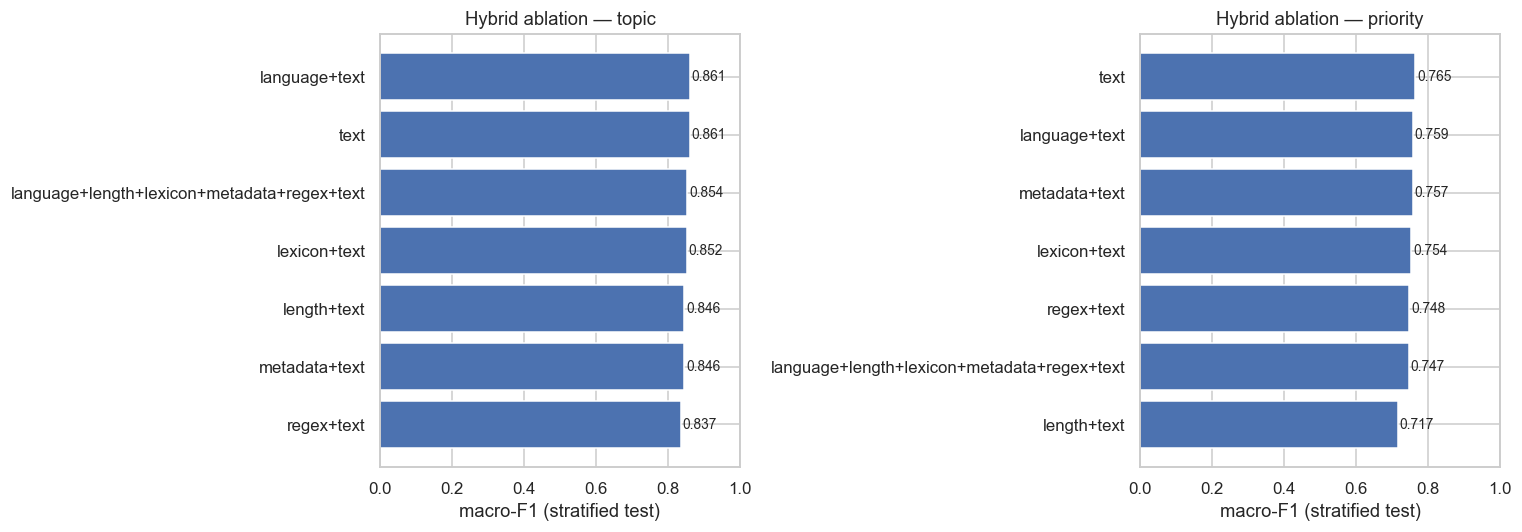

In [ ]:
def plot_ablation(task: str, ax):
    sub = (results_df[(results_df["task"] == task) & (results_df["split_type"] == "stratified")]
           .sort_values("macro_f1", ascending=True))
    ax.barh(sub["families"], sub["macro_f1"], color="#4C72B0")
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("macro-F1 (stratified test)")
    ax.set_title(f"Hybrid ablation — {task}")
    for y, v in enumerate(sub["macro_f1"]):
        ax.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_ablation("topic", axes[0])
plot_ablation("priority", axes[1])
plt.tight_layout()
plt.show()


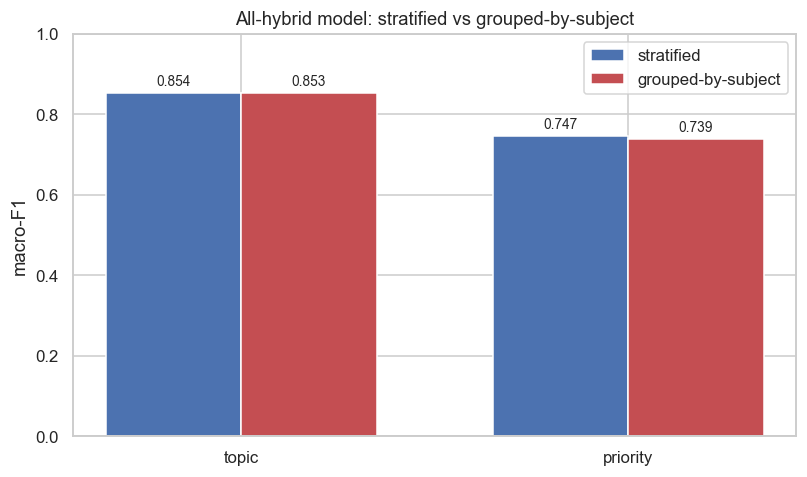

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
tasks = ["topic", "priority"]
all_label = "+".join(sorted({"text","length","language","metadata","regex","lexicon"}))
strat = [results_df[(results_df["task"] == t) & (results_df["split_type"] == "stratified")
                    & (results_df["families"] == all_label)]["macro_f1"].iloc[0] for t in tasks]
grp   = [results_df[(results_df["task"] == t) & (results_df["split_type"] == "grouped_subject")
                    & (results_df["families"] == all_label)]["macro_f1"].iloc[0] for t in tasks]

x = np.arange(len(tasks)); w = 0.35
b1 = ax.bar(x - w/2, strat, w, color="#4C72B0", label="stratified")
b2 = ax.bar(x + w/2, grp,   w, color="#C44E52", label="grouped-by-subject")
ax.set_xticks(x); ax.set_xticklabels(tasks)
ax.set_ylim(0, 1.0); ax.set_ylabel("macro-F1")
ax.set_title("All-hybrid model: stratified vs grouped-by-subject")
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


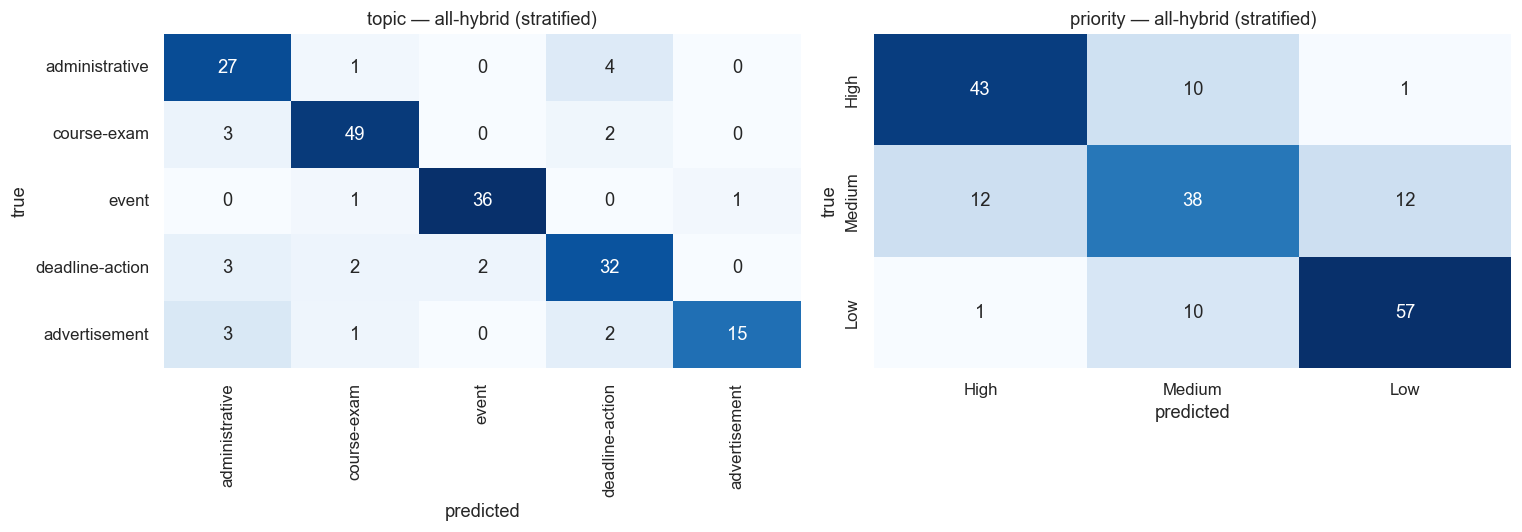

In [16]:
def confusion_for(task: str, families_label: str, split_type: str, ax):
    name = "text+all" if "+" in families_label and "lexicon" in families_label else "text"
    y_test, y_pred = PREDS[(task, name, split_type)]
    labels = TASK_LABELS[task]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{task} — all-hybrid ({split_type})")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_label = "+".join(sorted({"text","length","language","metadata","regex","lexicon"}))
confusion_for("topic",    all_label, "stratified", axes[0])
confusion_for("priority", all_label, "stratified", axes[1])
plt.tight_layout()
plt.show()


## 10 — Per-class report (best stratified hybrid model)


In [17]:
for task in ("topic", "priority"):
    y_test, y_pred = PREDS[(task, "text+all", "stratified")]
    print(f"=== {task.upper()} | text + length + language + metadata + regex + lexicon ===")
    print(classification_report(y_test, y_pred, labels=TASK_LABELS[task], zero_division=0))


=== TOPIC | text + length + language + metadata + regex + lexicon ===
                 precision    recall  f1-score   support

 administrative       0.75      0.84      0.79        32
    course-exam       0.91      0.91      0.91        54
          event       0.95      0.95      0.95        38
deadline-action       0.80      0.82      0.81        39
  advertisement       0.94      0.71      0.81        21

       accuracy                           0.86       184
      macro avg       0.87      0.85      0.85       184
   weighted avg       0.87      0.86      0.86       184

=== PRIORITY | text + length + language + metadata + regex + lexicon ===
              precision    recall  f1-score   support

        High       0.77      0.80      0.78        54
      Medium       0.66      0.61      0.63        62
         Low       0.81      0.84      0.83        68

    accuracy                           0.75       184
   macro avg       0.75      0.75      0.75       184
weighted avg   

## 11 — Error analysis

We focus on whether the hybrid features fixed the **`Medium` priority confusions** that pure-text models could not solve.


In [ ]:
def errors_for(task: str, name: str = "text+all"):
    idx_tr, idx_te = SPLITS_STRAT[task]
    y_test, y_pred = PREDS[(task, name, "stratified")]
    err = y_test != y_pred
    err_idx = np.array(idx_te)[err]
    out = pd.DataFrame({
        "id": df.loc[err_idx, "id"].values,
        "text_subject": df.loc[err_idx, "text_subject"].values,
        f"true_{task}": y_test[err],
        f"pred_{task}": y_pred[err],
        ("priority" if task == "topic" else "topic"):
            df.loc[err_idx, "priority" if task == "topic" else "topic"].values,
    })
    return out


# Topic
topic_err = errors_for("topic")
print(f"Topic errors: {len(topic_err)} / {len(SPLITS_STRAT['topic'][1])} "
      f"({len(topic_err)/len(SPLITS_STRAT['topic'][1])*100:.1f}%)")
print("\nConfusion types:")
print((topic_err["true_topic"] + " -> " + topic_err["pred_topic"]).value_counts().to_string())

# Priority — adjacency buckets
priority_err = errors_for("priority")
print(f"\nPriority errors: {len(priority_err)} / {len(SPLITS_STRAT['priority'][1])} "
      f"({len(priority_err)/len(SPLITS_STRAT['priority'][1])*100:.1f}%)")
print("\nConfusion types:")
print((priority_err["true_priority"] + " -> " + priority_err["pred_priority"]).value_counts().to_string())


def bucket(t, p):
    pair = frozenset([t, p])
    if pair == frozenset(["High", "Medium"]): return "High <-> Medium"
    if pair == frozenset(["Medium", "Low"]):  return "Medium <-> Low"
    if pair == frozenset(["High", "Low"]):    return "High <-> Low"
    return "same"


buckets = priority_err.apply(lambda r: bucket(r["true_priority"], r["pred_priority"]), axis=1)
print("\nAdjacency buckets:")
print(buckets.value_counts().to_string())
involves_medium = priority_err.apply(
    lambda r: "Medium" in (r["true_priority"], r["pred_priority"]), axis=1).sum()
print(f"\nErrors involving Medium: {involves_medium}  (03/04 baseline: 42)")


Topic errors: 25 / 184 (13.6%)

Confusion types:
administrative -> deadline-action    4
advertisement -> administrative      3
course-exam -> administrative        3
deadline-action -> administrative    3
deadline-action -> course-exam       2
deadline-action -> event             2
course-exam -> deadline-action       2
advertisement -> deadline-action     2
advertisement -> course-exam         1
event -> advertisement               1
administrative -> course-exam        1
event -> course-exam                 1

Priority errors: 46 / 184 (25.0%)

Confusion types:
Medium -> High    12
Medium -> Low     12
Low -> Medium     10
High -> Medium    10
Low -> High        1
High -> Low        1

Adjacency buckets:
Medium <-> Low     22
High <-> Medium    22
High <-> Low        2

Errors involving Medium: 44  (03/04 baseline: 42)


## 12 — Discussion

### What did each family contribute? (stratified macro-F1, Δ vs text-only)


In [ ]:
def deltas_for(task: str):
    text_only = results_df[(results_df["task"] == task)
                           & (results_df["split_type"] == "stratified")
                           & (results_df["families"] == "text")]["macro_f1"].iloc[0]
    rows = []
    for name, fam in ABLATION:
        if name == "text":
            continue
        f = results_df[(results_df["task"] == task)
                       & (results_df["split_type"] == "stratified")
                       & (results_df["families"] == "+".join(sorted(fam)))]["macro_f1"].iloc[0]
        rows.append({"families": name, "macro_f1": round(f, 4),
                     "Δ vs text": round(f - text_only, 4)})
    return pd.DataFrame(rows).sort_values("Δ vs text", ascending=False)


for task in ("topic", "priority"):
    print(f"\n--- {task.upper()} (text-only baseline) ---")
    print(deltas_for(task).to_string(index=False))



--- TOPIC (text-only baseline) ---
     families  macro_f1  Δ vs text
text+language    0.8610     0.0000
     text+all    0.8540    -0.0070
 text+lexicon    0.8524    -0.0086
  text+length    0.8462    -0.0148
text+metadata    0.8457    -0.0153
   text+regex    0.8370    -0.0240

--- PRIORITY (text-only baseline) ---
     families  macro_f1  Δ vs text
text+language    0.7588    -0.0064
text+metadata    0.7575    -0.0077
 text+lexicon    0.7536    -0.0116
   text+regex    0.7478    -0.0174
     text+all    0.7471    -0.0181
  text+length    0.7171    -0.0481


### Interpretation

The most important result is that hybrid features did not increase the optimistic stratified score (it slightly decreased) but clearly improved the grouped-by-subject score for both tasks (more than +5% macro-F1). This means the hybrid features made the model generalize better to unseen email templates, relying on general signals (dates, language, urgency cues, sender domain) instead of memorized subjects, rather than just inflating the easiest score.


## 13 — Final conclusion


In [20]:
def best_label(task):
    row = best_strat_row(task)
    return f"{row['families']} | macroF1={row['macro_f1']:.3f} acc={row['accuracy']:.3f}"


all_label = "+".join(sorted({"text","length","language","metadata","regex","lexicon"}))


def summary(task: str):
    text_g = grouped_row(task, "text")["macro_f1"]
    all_g  = grouped_row(task, all_label)["macro_f1"]
    text_s = results_df[(results_df["task"] == task)
                        & (results_df["split_type"] == "stratified")
                        & (results_df["families"] == "text")]["macro_f1"].iloc[0]
    all_s  = results_df[(results_df["task"] == task)
                        & (results_df["split_type"] == "stratified")
                        & (results_df["families"] == all_label)]["macro_f1"].iloc[0]
    return text_s, all_s, text_g, all_g


print("Hybrid feature engineering completed.\n")
for task in ("topic", "priority"):
    text_s, all_s, text_g, all_g = summary(task)
    print(f"--- {task.upper()} ---")
    print(f"  text-only  | strat={text_s:.3f}  grouped={text_g:.3f}")
    print(f"  all-hybrid | strat={all_s:.3f}  grouped={all_g:.3f}")
    print(f"  Δ          | strat={all_s-text_s:+.3f}  grouped={all_g-text_g:+.3f}")
    print(f"  best stratified configuration : {best_label(task)}")
    print()

print("Decision:")
print("  Use all-hybrid (text + length + language + metadata + regex + lexicon) as the")
print("  reference handcrafted system. Compare future transformer models against the")
print("  *grouped-by-subject* macro-F1 of this hybrid model.")


Hybrid feature engineering completed.

--- TOPIC ---
  text-only  | strat=0.861  grouped=0.804
  all-hybrid | strat=0.854  grouped=0.853
  Δ          | strat=-0.007  grouped=+0.049
  best stratified configuration : text | macroF1=0.861 acc=0.870

--- PRIORITY ---
  text-only  | strat=0.765  grouped=0.683
  all-hybrid | strat=0.747  grouped=0.739
  Δ          | strat=-0.018  grouped=+0.056
  best stratified configuration : text | macroF1=0.765 acc=0.766

Decision:
  Use all-hybrid (text + length + language + metadata + regex + lexicon) as the
  reference handcrafted system. Compare future transformer models against the
  *grouped-by-subject* macro-F1 of this hybrid model.
